# Cube Array of Rhombohedrons: MPB

This is continuing from the first example in the SquaresGalore notebook. All of the parameters will be re-defined here, but go check out [that tutorial](../SquaresGalore.ipynb#example2) if this looks too intimidating.

In [3]:
from crystalbuilder import *
import crystalbuilder.geometry as geo
import matplotlib.pyplot as plt
import numpy as np


In [9]:
a1 = [1, 0, 0]
a2 = [0, 1 ,0]
a3 = [0, 0, 1]
a_magnitude = 1
geo_lattice = lattice.Lattice(a1, a2, a3, magnitude = [a_magnitude, a_magnitude, a_magnitude])

## DIFFERENT FROM EXAMPLE 1:
rhombohedron_vectors = [
    [1,1,0],
    [0,1,1],
    [1,0,1]
]
rhomb = geo.Block(center=(0,0,0), vectors=rhombohedron_vectors, size=.5)

Let's load in MEEP and MPB, then define our material properties. Here we just use a generic material_1 with a user-defined refractive index. 

We also convert our crystal lattice and geometry to their MPB equivalents.

In [10]:
import meep as mp
from meep import mpb

mat1_index = 2.25

material_1 = mp.Medium(epsilon=(mat1_index*mat1_index))

mpb_lattice = convert.to_mpb_lattice(geo_lattice)
mpb_rhomb = convert.geo_to_mpb(rhomb, material=material_1, lattice=mpb_lattice)

# If you have additional geometry objects, you can use the `+` operator to combine them here
mpb_geometry = mpb_rhomb


Here is a block


Our lattice vectors are still those of a primitive cubic lattice, so we will use that lattice's Brillouin zone to build our list of k-vectors. 

The relevant points are:

$\Gamma$ = [0,0,0]

X = [0, $\frac{1}{2}$, 0]

R = [$\frac{1}{2}$, $\frac{1}{2}$, $\frac{1}{2}$]

M = [$\frac{1}{2}$, $\frac{1}{2}$, 0]


A good path is $\Gamma$-X-R-M-$\Gamma$

In [11]:
%%capture
#Let's scrap the output for legibility's sake. This cell should run in less than 20 seconds.


vlist = [
    mp.Vector3(0,0,0), #Gamma
    mp.Vector3(0, 1/2, 0), #X
    mp.Vector3(1/2, 1/2, 1/2), #R
    mp.Vector3(1/2, 1/2, 0), #M
    mp.Vector3(0,0,0) #Gamma
]
k_corners = len(vlist)
k_points = mp.interpolate(3, vlist)
tick_labs = ['$\Gamma$', 'X', 'R', 'M','$\Gamma$']


resolution = 16  # use a 16x16x16 grid
mesh_size = 1
num_bands = 10

ms = mpb.ModeSolver(
    geometry_lattice=mpb_lattice,
    k_points=k_points,
    geometry=mpb_geometry,
    resolution=resolution,
    num_bands=num_bands,
    mesh_size=mesh_size
)
ms.optimize_grid_size=True

ms.run()

epsilon: 1-5.0625, mean 1.33821, harm. mean 1.07159, 8.3252% > 1, 8.3252% "fill"
real part range: 1 .. 5.0625


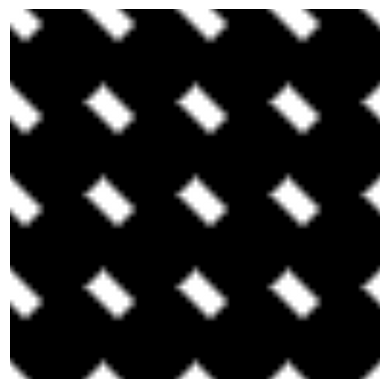

In [12]:
## Plotting Dielectric Map ###
plt.figure()
md = mpb.MPBData(rectify=True, periods=4, resolution=64)
eps = ms.get_epsilon()
converted_eps = md.convert(eps)
layer_slice = 10
plt.imshow(converted_eps[:,:, layer_slice], interpolation='spline36', cmap='binary_r')
plt.axis('off')
plt.show()


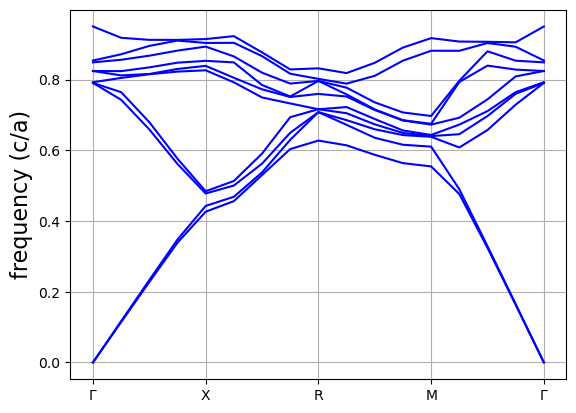

In [13]:
### Plotting Band Structure ###
crysfreqs = ms.all_freqs
x = range(len(crysfreqs))
figgy = plt.figure()
plt.plot(x,crysfreqs, color='blue')
plt.ylabel('frequency (c/a)', size=16)
plt.grid(True)
figax = plt.gca()

points_in_between = (len(crysfreqs)-1) / (k_corners-1)
tick_locs = [i*points_in_between for i in range(k_corners)]

plt.xticks(tick_locs,tick_labs)

plt.show()